# SKM quickstart: load, filter, find a path, and add your own data

This notebook is a short, self-contained introduction to working with the **Stress Knowledge Map (SKM)** programmatically, using the [`skm-tools`](https://github.com/NIB-SI/skm-tools) Python package.

We will:
1. Load the live **PSS** (Plant Stress Signalling) network from [skm.nib.si](https://skm.nib.si)
2. Filter it down to a targeted subset
3. Find a short signalling path between two nodes of interest (the plant hormones **JA** and **SA**)
4. Attach a small (mock) gene expression dataset to the nodes
5. Visualise the result using `networkx` and `matplotlib`

> This notebook is meant to run top-to-bottom in Google Colab with no local setup.

## 1. Setup

We install `skm-tools` directly from GitHub, and import the libraries we need.

In [1]:
!pip install -q "skm-tools @ git+https://github.com/NIB-SI/skm-tools.git"

  Preparing metadata (setup.py) ... done


In [2]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

today = datetime.today().strftime("%Y.%m.%d")
today

'2026.09.02'

In [3]:
from skm_tools import load_networks, pss_utils

In [4]:
today = datetime.today().strftime("%Y.%m.%d")
today

'2026.09.02'

## 2. Load PSS

We download and load the current, live PSS network. For a description of the underlying files and specific projections, see [skm.nib.si/downloads](https://skm.nib.si/downloads).

In [5]:
data_dir = Path("./data")
data_dir.mkdir(exist_ok=True)

pss_edge_path = data_dir / f"rxn-edges-public-{today}.tsv"
pss_node_path = data_dir / f"rxn-nodes-public-{today}.tsv"

g = load_networks.pss_to_networkx(
    edge_path=pss_edge_path,
    node_path=pss_node_path,
)

print(f"Number of nodes: {g.number_of_nodes()}")
print(f"Number of edges: {g.number_of_edges()}")

Number of nodes: 754
Number of edges: 1585


## 3. Filter

PSS covers multiple species and node types. To keep things simple and quick to plot, we filter down to one species (Arabidopsis, `ath`) and a couple of node types.

In [6]:
keep_types = ["PlantCoding", "Process", "Metabolite"]
species = ["ath"]

removed = pss_utils.filter_pss_nodes(
    g,
    node_types=keep_types,
    species=species,
    remove_isolates=True,
)

print(f"Number of nodes: {g.number_of_nodes()}")
print(f"Number of edges: {g.number_of_edges()}")

Removed 254 nodes from network.
Number of nodes: 500
Number of edges: 999


## 4. Find a path

As a simple, example, we look at the shortest path between two well-known signalling hormones: **JA** (jasmonic acid) and **SA** (salicylic acid).

In [7]:
JA = [n for n, d in g.nodes(data=True) if d.get("name") == "JA"][0]
SA = [n for n, d in g.nodes(data=True) if d.get("name") == "SA"][0]

path = nx.shortest_path(g, source=JA, target=SA)
print(len(path))

10


## 5. Build a small subnetwork

We pull out the path itself, plus each path node's direct neighbourss. All done with the  `networkx` library.

In [8]:
nodes_of_interest = set(path)

neighbours = set()
for n in path:
    neighbours.update(g.neighbors(n))

sub_nodes = nodes_of_interest | neighbours
subG = g.subgraph(sub_nodes).copy()

print(f"Subnetwork: {subG.number_of_nodes()} nodes, {subG.number_of_edges()} edges")

Subnetwork: 33 nodes, 62 edges


## 6. Add a (mock) gene expression dataset

In a real analysis, this would be your own differential expression results (e.g. log fold-change from an RNA-seq contrast), matched to PSS nodes by identifier.

Here we generate a small **mock** dataset by assigning random log fold-change values to a subset of the nodes already in our subnetwork.

In [9]:
rng = np.random.default_rng(42)

node_ids = list(subG.nodes())
sample_size = max(1, int(len(node_ids) * 0.6))
sampled_ids = rng.choice(node_ids, size=sample_size, replace=False)

expression_df = pd.DataFrame({
    "node_id": sampled_ids,
    "gene_name": [subG.nodes[n].get("name", n) for n in sampled_ids],
    "logFC": rng.normal(loc=0, scale=1.5, size=sample_size).round(2),
})

expression_df.head()

,node_id,gene_name,logFC
0,"GH3[AT2G47750,AT4G27260,FUN_031316,MALDO.HC.V1...","GH3[AT2G47750,AT4G27260,FUN_031316,MALDO.HC.V1...",-0.07
1,SAG,SAG,-0.28
2,N-pyruvoyl-L-Glu,N-pyruvoyl-L-Glu,-1.02
3,"SAMC[AT1G34065,AT4G39460,FUN_020798,FUN_027909...","SAMC[AT1G34065,AT4G39460,FUN_020798,FUN_027909...",1.83
4,"JAZ[AT1G17380,AT1G19180,AT1G30135,AT1G48500,AT...","JAZ[AT1G17380,AT1G19180,AT1G30135,AT1G48500,AT...",-0.23


## 7. Visualise

We draw the subnetwork with `networkx` + `matplotlib`:
- Node colour = mock log fold-change (blue = down, red = up, grey = no data)
- The JA→SA path is highlighted with thicker, coloured edges
- Node labels use the `display_label` attribute

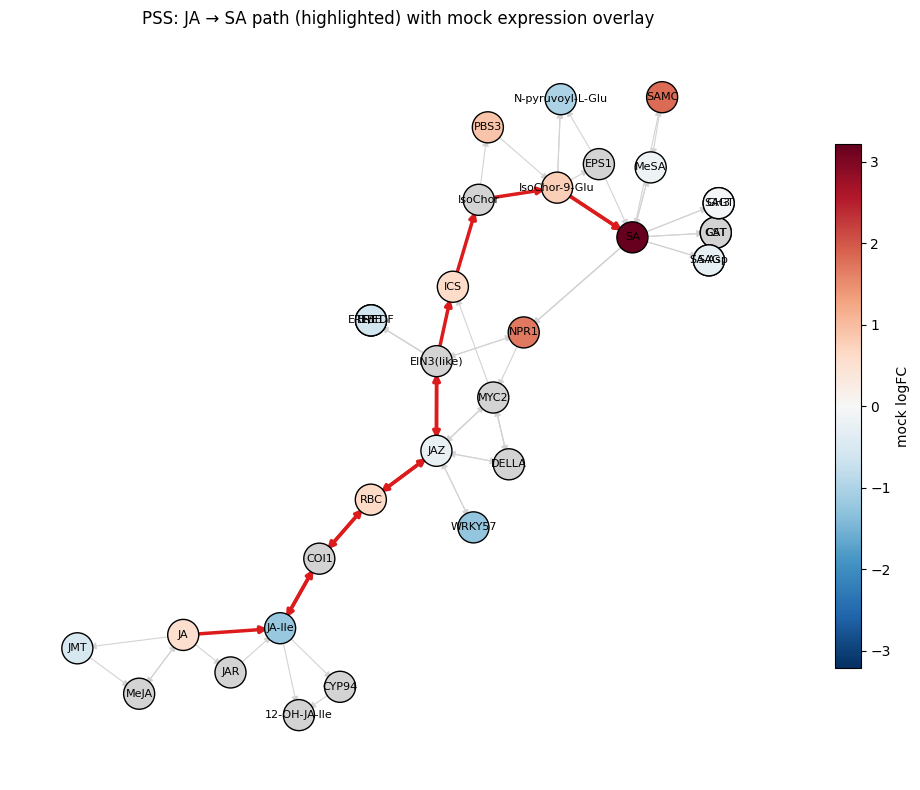

In [11]:
# === Node styles ===
expr_lookup = dict(zip(expression_df["node_id"], expression_df["logFC"]))

vmax = expression_df["logFC"].abs().max()
cmap = plt.cm.RdBu_r
norm = plt.Normalize(vmin=-vmax, vmax=vmax)

node_colors = [
    cmap(norm(expr_lookup[n])) if n in expr_lookup else "lightgrey"
    for n in subG.nodes()
]

labels = {n: subG.nodes[n].get("display_label", n) for n in subG.nodes()}

# === Edge styles ===

path_edges = set(zip(path[:-1], path[1:]))
edge_colors = [
    "#dc1c1c" if (u, v) in path_edges or (v, u) in path_edges else "lightgrey"
    for u, v in subG.edges()
]
edge_widths = [
    2.5 if (u, v) in path_edges or (v, u) in path_edges else 0.8
    for u, v in subG.edges()
]

# === Layout and draw ===

pos = nx.kamada_kawai_layout(subG)

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(subG, pos, edge_color=edge_colors, width=edge_widths, ax=ax)
nx.draw_networkx_nodes(subG, pos, node_color=node_colors, edgecolors="black", node_size=500, ax=ax)
nx.draw_networkx_labels(subG, pos, labels=labels, font_size=8, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="mock logFC", shrink=0.7)

ax.set_title("PSS: JA \u2192 SA path (highlighted) with mock expression overlay")
ax.axis("off")
plt.tight_layout()
plt.show()

## Next steps

Further options:
- Load your **own** expression/omics data instead of the mock dataset, matched by gene identifier
- Try different node types, species, or start/end nodes for the path search
- Explore the full **CKN** network (480,000+ interactions) the same way, via `load_networks`
- For richer, interactive network visualisation, `skm-tools` also has a Cytoscape automation utilities (`cytoscape_utils`)

More: [skm.nib.si](https://skm.nib.si) · [skm-tools on GitHub](https://github.com/NIB-SI/skm-tools)